# Solar generation dataset

This notebook downloads weather data, runs a pvlib model, and exports the aligned dataset used by the microgrid simulator. Parameters live in one configuration cell so the experiment is reproducible.

In [1]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pvlib
from pvlib import modelchain, pvsystem, solarposition
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS

from src.components.Solar import PVLibWeatherFetcher

PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_DIRECTORY = PROJECT_ROOT / 'src' / 'data'
DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
START_DATE = 20181231
END_DATE = 20200101
LOCATION_NAME = 'Кош-Агач'


In [2]:
weather_fetcher = PVLibWeatherFetcher(user_agent='masters-thesis-notebook')
weather_data, weather_metadata, site_location = weather_fetcher.fetch(LOCATION_NAME, START_DATE, END_DATE)
weather_data.to_csv(DATA_DIRECTORY / 'weather.csv')
weather_data.head()


,dni,dhi,ghi,temp_air,wind_speed
2018-12-31 00:00:00+00:00,0.00,0.00,0.00,-19.85,1.76
2018-12-31 01:00:00+00:00,0.00,0.00,0.00,-20.05,1.74
2018-12-31 02:00:00+00:00,39.99,20.73,18.38,-19.97,1.86
2018-12-31 03:00:00+00:00,94.12,60.96,77.62,-18.79,1.91
2018-12-31 04:00:00+00:00,119.79,104.09,136.02,-16.87,1.61


In [3]:
times = pd.date_range(start=datetime.strptime(str(START_DATE), '%Y%m%d'),
                      end=datetime.strptime(str(END_DATE), '%Y%m%d'), freq='h', tz=site_location.tz)
solar_position = solarposition.get_solarposition(times, site_location.latitude, site_location.longitude, site_location.altitude)
weather_data.index = pd.to_datetime(weather_data.index).tz_convert(site_location.tz)
weather_data = weather_data.reindex(times)
weather_data.describe()


,dni,dhi,ghi,temp_air,wind_speed
count,8778.000000,8778.000000,8778.000000,8778.000000,8778.000000
mean,200.006352,69.326005,164.482748,-3.131062,3.348864
std,280.760696,96.276235,232.552945,12.628396,1.979360
min,0.000000,0.000000,0.000000,-33.080000,0.010000
25%,0.000000,0.000000,0.000000,-13.857500,2.032500
50%,4.835000,9.870000,8.975000,-1.960000,2.910000
75%,371.627500,116.042500,291.375000,6.740000,4.110000
max,1023.970000,509.870000,969.220000,25.150000,18.760000


In [4]:
MODULE_PARAMETERS = {
    'Name': 'HVL-320', 'Technology': 'CIGS', 'Bifacial': None, 'STC': 320,
    'PTC': 300, 'A_c': 1.67, 'Length': 1.671, 'Width': 1.002, 'N_s': 60,
    'I_sc_ref': 9.33, 'V_oc_ref': 43.97, 'I_mp_ref': 8.62, 'V_mp_ref': 35.36,
    'alpha_sc': 0.037, 'beta_oc': -0.249, 'T_NOCT': 38.8, 'a_ref': 1.8,
    'I_L_ref': 9.33, 'I_o_ref': 1e-10, 'R_s': 0.35, 'R_sh_ref': 1000,
    'Adjust': 1, 'gamma_r': -0.39, 'BIPV': False,
}
tracker_mount = pvsystem.SingleAxisTrackerMount(axis_tilt=0, axis_azimuth=0, max_angle=60, backtrack=True, gcr=0.4)
array = pvsystem.Array(mount=tracker_mount, module_parameters=MODULE_PARAMETERS, modules_per_string=100, strings=13, temperature_model_parameters=TEMPERATURE_MODEL_PARAMETERS['pvsyst']['freestanding'])
inverter_parameters = pvlib.pvsystem.retrieve_sam('cecinverter')['AEG_Power_Solutions__Protect_MPV_030_01__480V_']
system = pvsystem.PVSystem(arrays=[array], inverter_parameters=inverter_parameters)
model = modelchain.ModelChain(system, site_location, aoi_model='physical', spectral_model='no_loss')
model.run_model(weather_data)


C:\Users\Илья\PycharmProjects\masters-thesis\.venv1\lib\site-packages\scipy\optimize\_chandrupatla.py:438: RuntimeWarning: invalid value encountered in divide
  C = A / (A + B)


ModelChain: 
  name: None
  clearsky_model: ineichen
  transposition_model: haydavies
  solar_position_method: nrel_numpy
  airmass_model: kastenyoung1989
  dc_model: cec
  ac_model: sandia_inverter
  aoi_model: physical_aoi_loss
  spectral_model: no_spectral_loss
  temperature_model: pvsyst_temp
  losses_model: no_extra_losses

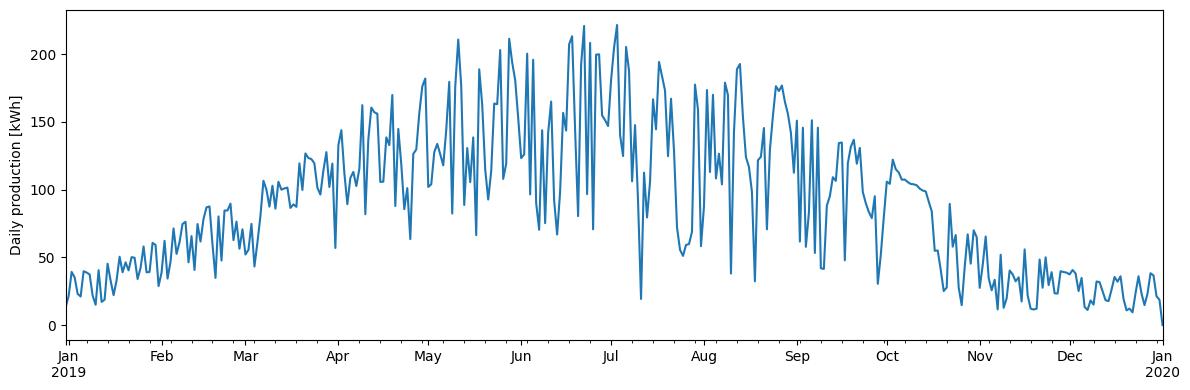

In [5]:
daily_energy_kwh = model.results.dc['p_mp'].resample('D').mean().div(1000)
daily_energy_kwh.plot(figsize=(12, 4), ylabel='Daily production [kWh]')
plt.tight_layout()
plt.show()


In [6]:
load_data = pd.read_excel(DATA_DIRECTORY / 'data.xlsx', index_col=0)
load_data.index = pd.to_datetime(load_data.index).tz_localize('Asia/Krasnoyarsk')
combined_data = pd.concat([model.results.dc, load_data.reindex(model.results.dc.index)], axis=1).dropna()
combined_data = combined_data.drop(columns=['Solal, kW'], errors='ignore').rename(columns={'Нагрузка, kW': 'Load, kW'})
combined_data['Solar, kW'] = combined_data['p_mp'] * 1e-3
combined_data.index.name = 'datetime'
combined_data.index = combined_data.index.tz_localize(None)
combined_data.to_excel(DATA_DIRECTORY / 'dataset.xlsx')
combined_data.head()


,i_sc,v_oc,i_mp,v_mp,p_mp,i_x,i_xx,"Сасыр, kW","Solar, kW"
datetime,,,,,,,,,
2019-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,201.000791,0.0
2019-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,179.721422,0.0
2019-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,171.304978,0.0
2019-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,173.068636,0.0
2019-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,159.528222,0.0
